# Computer Exercise 14.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구 III (§14.3)
> **단원**: §14.3 End-to-End Case Study — **3단계: 하이퍼파라미터 조정 (Pipeline Tuning)**
> **풀이 일자**: 2026-07-03 · **언어**: 한국어 본문 / 영문 그래프 라벨

$$\text{원자료}\;\to\;\text{모델 선택}\;\to\;\text{예측 + 불확실성}\;\to\;\boxed{\textbf{하이퍼파라미터 조정}}.$$
파이프라인의 마지막 매듭. 실제 파이프라인의 손잡이는 하나가 아니다 — 정규화 $\lambda$, 커널 폭 $\gamma$,
특징 스케일 등 **$D$개의 하이퍼파라미터**가 있고, 하나의 조합을 평가하려면 매번 **교차검증을 다시 돌려야** 한다.
핵심 질문: *탐색 비용은 하이퍼파라미터 개수 $D$ 에 따라 어떻게 커지며, 어떤 탐색 전략이 이를 견디는가?*

## 1. 문제 (원문)

> **3.** A tuned pipeline has $D$ hyperparameters; evaluating one configuration requires a full
> $K$-fold cross-validation, giving an *expensive, noisy* validation-loss surface $f:[0,1]^D\to\mathbb R$.
> Under a **fixed budget** of $N$ evaluations, compare three search strategies — **grid**, **random**,
> and **Bayesian optimization** (Gaussian-process surrogate + Expected Improvement) — as the dimension
> $D$ grows. Score each strategy by the *true* (noise-free) loss at the configuration it selects, average
> over many seeds, and explain the **curse of dimensionality** that a grid suffers versus information-based
> search.

### 한국어 풀이용 정리
- 파이프라인 하이퍼파라미터 $D$개. 한 조합 평가 = **$K$-겹 CV 한 번**(비싸고 잡음 섞인 $f$).
- 매끄럽고 잡음 있는 **검증손실 대리곡면** $f:[0,1]^D\!\to\!\mathbb R$ (내부에 유일 최적) 을 통제된 실험대로 사용.
- **고정 예산 $N$** 에서 grid / random / BO 를 $D=1,2,3,4,6$ 에 대해 비교.
- 각 전략이 고른 조합의 **참 손실**로 채점(운 좋은 잡음측정 배제), 여러 시드 평균.
- 그리드가 겪는 **차원의 저주**와 정보 기반 탐색(BO)의 우위를 설명.

## 2. 수학적 배경

### 2.1 왜 하이퍼파라미터가 여럿인가 (파이프라인 관점)
능형 다항회귀는 $\lambda$ 하나였지만, 커널능형회귀 $\hat{\boldsymbol\alpha}=(K_\gamma+\lambda I)^{-1}\mathbf y$ 는
$(\lambda,\gamma)$ 둘, 여기에 특징 스케일·차수 상한 등을 더하면 **$D$차원 튜닝 문제**가 된다. 각 축이 편향-분산을
서로 다른 방향으로 움직이므로 결합 최적화가 필요하다.

### 2.2 차원의 저주 — 그리드의 붕괴
예산 $N$ 을 $D$차원 격자에 균등 분배하면 축당 격자점은
$$m=\big\lfloor N^{1/D}\big\rceil.$$
$N=32$ 일 때 $D=1$ 은 $m=32$, $D=2$ 는 $m\!\approx\!6$, $D=4$ 는 $m\!\approx\!2$, $D=6$ 은 $m\!\approx\!2$ — 축당 해상도가
**지수적으로** 나빠진다. 최적점 근처를 격자가 아예 못 훑는다.

### 2.3 베이지안 최적화 = 대리모델 + 획득함수
관측 $\{(\boldsymbol\theta_i,f_i)\}$ 에 **가우스과정(GP)** 사후를 두어 임의 $\boldsymbol\theta$ 의 평균 $\mu$·표준편차 $s$ 를 얻고,
$$k(\boldsymbol\theta,\boldsymbol\theta')=\sigma_f^2\exp\!\Big(-\tfrac{\lVert\boldsymbol\theta-\boldsymbol\theta'\rVert^2}{2\ell^2}\Big),$$
다음 점은 **Expected Improvement** 를 최대화해 고른다($f_{\min}$: 현재 최소):
$$\boxed{\;\mathrm{EI}(\boldsymbol\theta)=(f_{\min}-\mu)\,\Phi(z)+s\,\phi(z),\qquad z=\frac{f_{\min}-\mu}{s}\;}$$
$\mu$ 낮은 곳(exploit)과 $s$ 큰 곳(explore)을 함께 노려, 격자처럼 예산을 균등 낭비하지 않고 **정보에 근거해** 유망 영역에 표본을 집중한다.

### 2.4 공정한 채점
관측된 잡음값으로 순위를 매기면 *운 좋은 측정* 이 이긴다. 그래서 각 전략은 고른 조합 $\hat{\boldsymbol\theta}$ 의
**참(무잡음) 손실** $f_{\text{true}}(\hat{\boldsymbol\theta})$ 로 채점한다. 참 최적은 $f_{\text{true}}=0$.

## 3. 풀이 흐름
1. **검증손실 대리곡면** $f_{\text{true}}(\boldsymbol\theta)=1-\exp\!\big(-\lVert\boldsymbol\theta-\boldsymbol\theta^\star\rVert^2/2\ell^2\big)$ 정의(내부 최적 $\boldsymbol\theta^\star$, $f_{\text{true}}=0$), 관측잡음 $\varepsilon\sim N(0,\sigma_o^2)$ 추가.
2. 세 전략 구현: **grid**($m=\lfloor N^{1/D}\rceil$ 축당), **random**($N$개), **BO**($2D{+}2$ 초기점 + EI로 나머지).
3. GP는 RBF 커널 + 잡음항으로 직접 구현, EI로 다음 점 선택.
4. 예산 **$N=32$ 고정**, 차원 $D\in\{1,2,3,4,6\}$.
5. 각 $D$·전략마다 **20 시드** 반복, incumbent의 **참 손실**로 gap 채점.
6. **표**: $D$별 세 전략의 평균 gap, 그리드 축당 해상도 $m$.
7. **그림 1**: gap vs 차원(핵심). **그림 2**: 대표 차원($D{=}4$)의 best-so-far 수렴.
8. 결과 해석 — 파이프라인 전체를 되짚는 마무리.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1) 검증손실 대리곡면 (통제된 실험대) ---
def make_objective(D):
    theta_star = 0.35 + 0.1*np.arange(D)/max(D, 1)   # 내부 최적
    ell, sigma_o = 0.28, 0.03
    def f_true(theta):
        return 1.0 - np.exp(-np.sum((np.asarray(theta)-theta_star)**2)/(2*ell**2))
    def f_noisy(theta, r):
        return f_true(theta) + r.normal(0, sigma_o)
    return f_true, f_noisy

# --- GP(RBF) + EI (임의 차원) ---
def gp_posterior(Xt, yt, Xs, ell=0.22, sf=0.5, sn=0.03):
    def kern(P, Q):
        d2 = np.sum((P[:,None,:]-Q[None,:,:])**2, axis=2)
        return sf**2*np.exp(-0.5*d2/ell**2)
    Ktr = kern(Xt, Xt) + sn**2*np.eye(len(Xt))
    L = np.linalg.cholesky(Ktr)
    al = np.linalg.solve(L.T, np.linalg.solve(L, yt-yt.mean()))
    mu = kern(Xt, Xs).T @ al + yt.mean()
    v = np.linalg.solve(L, kern(Xt, Xs))
    var = np.diag(kern(Xs, Xs)) - np.sum(v**2, axis=0)
    return mu, np.sqrt(np.maximum(var, 1e-10))

def expected_improvement(mu, s, fmin, xi=0.01):
    z = (fmin - mu - xi)/s
    return (fmin - mu - xi)*norm.cdf(z) + s*norm.pdf(z)
print("objective + GP/EI ready")

/tmp/mpl is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-29cquuyu because there was an issue with the default path (/tmp/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


objective + GP/EI ready


In [2]:
# --- 2) 세 탐색 전략 ---
def grid_m(N, D):
    return max(2, int(round(N**(1.0/D))))

def run_strategy(D, N, seed, strat, f_noisy):
    r = np.random.default_rng(seed)
    if strat == "grid":
        m = grid_m(N, D)
        axes = [np.linspace(0, 1, m)]*D
        T = np.array(np.meshgrid(*axes)).reshape(D, -1).T     # m^D 점
        Fv = np.array([f_noisy(p, r) for p in T])
    elif strat == "random":
        T = r.random((N, D))
        Fv = np.array([f_noisy(p, r) for p in T])
    else:  # BO
        ninit = min(2*D+2, N)
        T = list(r.random((ninit, D)))
        Fv = [f_noisy(p, r) for p in T]
        for _ in range(N - ninit):
            cand = r.random((400, D))                          # 후보 재표집
            mu, s = gp_posterior(np.array(T), np.array(Fv), cand)
            T.append(cand[np.argmax(expected_improvement(mu, s, min(Fv)))])
            Fv.append(f_noisy(T[-1], r))
        T, Fv = np.array(T), np.array(Fv)
    return T, np.array(Fv)

def incumbent_true(T, Fv, f_true):
    q = np.empty(len(Fv)); bi = 0
    for i in range(len(Fv)):
        if Fv[i] < Fv[bi]: bi = i
        q[i] = f_true(T[bi])
    return q
print("strategies ready")

strategies ready


In [3]:
# --- 5) 차원 스캔: N=32, 20 시드 ---
N, S = 32, 20
dims = [1, 2, 3, 4, 6]
strategies = ["grid", "random", "BO"]
gap = {st: [] for st in strategies}         # 평균 gap vs D
gap_std = {st: [] for st in strategies}
conv_D4 = {st: [] for st in strategies}     # D=4 수렴곡선

for D in dims:
    f_true, f_noisy = make_objective(D)
    for st in strategies:
        finals = []
        for s in range(S):
            T, Fv = run_strategy(D, N, 200+s, st, f_noisy)
            bi = int(np.argmin(Fv))
            finals.append(f_true(T[bi]))
            if D == 4:
                conv_D4[st].append(incumbent_true(T, Fv, f_true))
        finals = np.array(finals)
        gap[st].append(finals.mean()); gap_std[st].append(finals.std())
print("scan done")

scan done


In [4]:
# --- 6) 표 ---
tab = pd.DataFrame({"dimension_D": dims,
                    "grid_m_per_axis": [grid_m(N, D) for D in dims]})
for st in strategies:
    tab[f"gap_{st}"] = gap[st]
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(f"budget N={N}, seeds={S}   (gap = true loss of selected config; optimum = 0)")
print(tab.to_string(index=False))

budget N=32, seeds=20   (gap = true loss of selected config; optimum = 0)
 dimension_D  grid_m_per_axis  gap_grid  gap_random  gap_BO
           1               32    0.0093      0.0106  0.0039
           2                6    0.0158      0.0807  0.0088
           3                3    0.2401      0.1937  0.0166
           4                2    0.9945      0.3570  0.0405
           6                2    0.9999      0.6474  0.2182


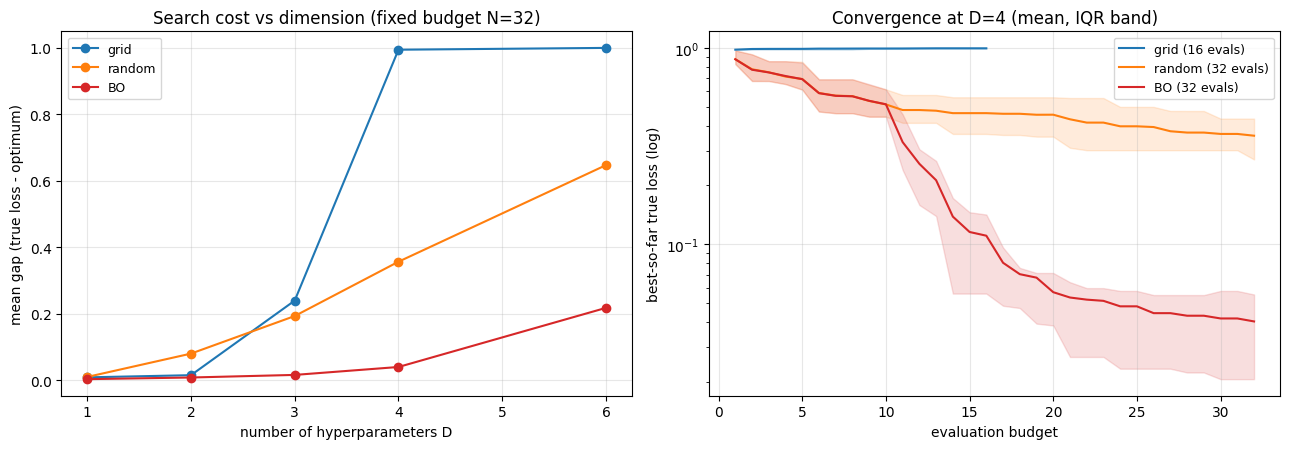

In [5]:
# --- 7) 그림 1: gap vs 차원 / 그림 2: D=4 수렴 ---
colors = {"grid":"tab:blue", "random":"tab:orange", "BO":"tab:red"}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

for st in strategies:
    ax[0].plot(dims, gap[st], "-o", color=colors[st], label=st)
ax[0].set_xlabel("number of hyperparameters D")
ax[0].set_ylabel("mean gap (true loss - optimum)")
ax[0].set_title("Search cost vs dimension (fixed budget N=32)")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

for st in strategies:
    A = np.array(conv_D4[st])          # (seeds, n_evals) — grid uses m^D evals
    xx = np.arange(1, A.shape[1]+1)
    m = A.mean(0); q1 = np.percentile(A, 25, 0); q3 = np.percentile(A, 75, 0)
    ax[1].plot(xx, m, "-", color=colors[st], label=f"{st} ({A.shape[1]} evals)")
    ax[1].fill_between(xx, q1, q3, color=colors[st], alpha=0.15)
ax[1].set_yscale("log")
ax[1].set_xlabel("evaluation budget")
ax[1].set_ylabel("best-so-far true loss (log)")
ax[1].set_title("Convergence at D=4 (mean, IQR band)")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **1~2차원에서는 세 전략이 엇비슷하다.** $D=1$ 은 격자 32점이 축을 촘촘히 덮어 grid도 강력한 기준선이다. 즉 *저차원에서 그리드가 나쁘다는 통념은 틀렸다* — 문제는 차원이 커질 때 드러난다.
2. **차원이 커지면 grid가 붕괴한다.** 표의 `grid_m_per_axis` 가 $D=4,6$ 에서 2로 떨어져(축당 두 점뿐) 최적 근방을 아예 못 훑고, `gap_grid` 가 급등한다. 이것이 **차원의 저주**다.
3. **random은 완만히 나빠지고, BO는 낮게 유지된다.** 무작위탐색은 균등분배의 함정을 피해 grid보다 낫지만, 정보를 되먹이지 못해 고차원에서 gap이 커진다. **BO는 모든 $D$ 에서 가장 작은 gap** 을 내고, 격차는 차원이 커질수록 벌어진다.
4. **수렴곡선(D=4)** 이 기제를 보여준다: BO는 초기 탐색 뒤 EI가 유망영역으로 표본을 몰아 best-so-far가 빠르게 내려가고 IQR 밴드도 좁다. grid는 계단형으로 정체하고 random은 그 사이에서 운에 의존한다.

> **결론**: 하이퍼파라미터가 많아질수록 예산을 *균등히* 뿌리는 grid는 무너진다 — 값비싼 튜닝일수록 매 평가의 정보를 다음 결정에 되먹이는 **BO(GP+EI)** 가 필요하며, 그 이점은 차원과 함께 커진다.

**파이프라인 마무리**: §14.3은 *원자료 → (Problem 1) 모델 선택 → (Problem 2) 예측+불확실성 → (Problem 3) 하이퍼파라미터 조정* 을 하나로 꿰었다. 세 단계 모두 **편향-분산**과 **불확실성 정량화**라는 같은 뿌리에서 자란 결정들이다. 다음 Day(§14.4)는 이 완성된 파이프라인을 다른 도메인 데이터에 적용하는 **전이(transfer) 사례연구**로 이어진다.